# Lesson 1. Build and run your first quantum program

## Set up

We start a number of imports. `QuantumCircuit` class is where we define our qubits. `plot_histogram` will be used to to visualize the results of our quantum circuit. `AerSimulator` allows us to simulate the quantum circuit on a classical computer. The `preset_passsmanagers` help optimize the circuit to run efficiently on hardware. `Sampler` and `QiskitRuntimeService` are necessary yo actually run the circuit on the quantum computer.

In [3]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

We'll do a quick environment check to confirm versions and imports.

In [4]:
import sys

import qiskit
import qiskit_aer
import qiskit_ibm_runtime

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.9
qiskit: 2.4.2
qiskit-aer: 0.17.0
qiskit-ibm-runtime: 0.47.0


## Create and run a quantum program using Qiskit
We're going to generate the $\Phi^+$ Bell state. To build the state circuit, we use an **$H$** (Hadamard) gate to put the first qubit into an equal superposition. Then we apply a **$CX$** (Controlled-NOT) gate, which entangles the two states together. The two qubits are now correlated in a way that has no classical equivalent.



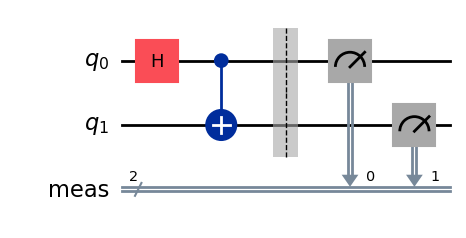

In [5]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all() # creates a classical register named "meas"
bell.draw("mpl")

### Helper function for running circuits
Now lets define a helper function that handles the process of runniing a quantum circuit and retrieving measurements results. This function takes care of transpiling the circuit to match the backend's instruction set, running it through a `Sampler` primitive, and extracting the counts from the results.

In [6]:
def run_circuit_and_get_counts(circuit, backend, shots = 1000):
    """ 
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args: 
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.
    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

### Run on a QPU and visualize results

Finally, we run the circuit on an IBM quantum processing unit (QPU) in the cloud for 1000 shots and plot the results. IBM QPUs are physical systems that can pick up noise, so gates are slightly imperfect, measurements can be wrong sometimes, and device calibration drifts over time.

Running on real quantum computers also introduces practical considerations. Jobs can sit in a queue, because many people may be using the same device. You also have to choose a shot count that balances statistical considerations (more shots equals a higher signal-to-noise ratio) with time/cost constraints.

Follow the instructions in the code comments of the next cell. After running the cell, you should see a histogram with approximately equal counts for the 00 and 11 bitstrings, with some occurrences of 01 or 10 due to noise. The following cell in this notebook runs the same circuit on a simulator, should you choose to skip running on a QPU.

In [ ]:
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False,min_num_qubits=127)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-06-13 18:04:00,929: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-06-13 18:04:01,083: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-06-13 18:04:03,738: Using instance: open-instance, plan: open


ibm_fez


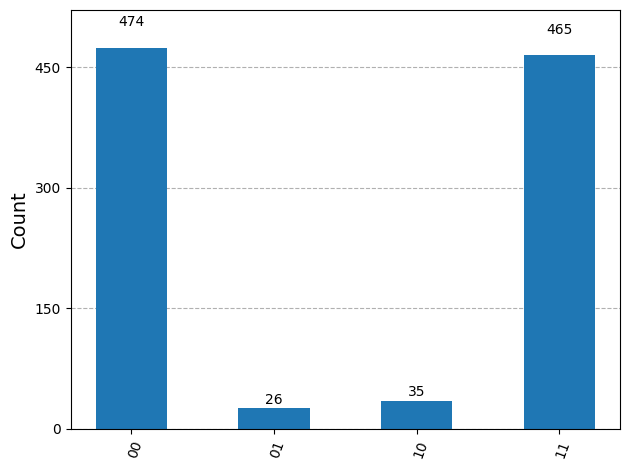

In [8]:
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

### Run on a simulator and visualize results

A simulator is a "perfect world" version of quantum computing. Here we run the circuit on a simulator for 1000 shots and plot the results. You should see approximately equal counts for the $00$ and $11$ states, with no occurrences of $01$ or $10$, which is the signature of the Bell state's perfect correlation.

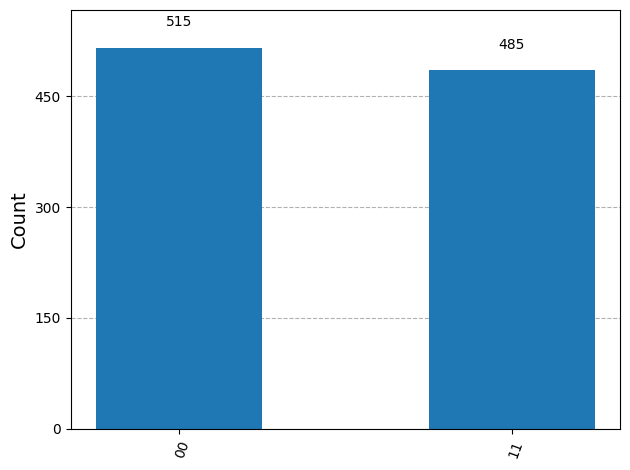

In [9]:
backend = AerSimulator()
counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

## Conclusion

We  built a simple two-qubit circuit that produces the **$\Phi^+$** Bell state and used repeated sampling and visualized the entanglement as a correlation in the qubit measurement histogram. We also saw how real quantum computers introduce noise and errors.